In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# Add the project root to the path so we can import our modules
# Use '..' to go up one level from 'notebooks' to 'Neural-Network-Scratch'
sys.path.append(os.path.abspath(os.path.join('..')))

from src.model import train
from utils.data_loader import load_mnist_data

In [2]:
# Assuming your data folder is in the same directory as 'src' and 'utils'
X_train, Y_train = load_mnist_data('../data/mnist_train.csv')

print(f"X_train shape: {X_train.shape}") # Goal: (784, 60000)
print(f"Y_train shape: {Y_train.shape}") # Goal: (10, 60000)

X_train shape: (784, 60000)
Y_train shape: (10, 60000)


In [3]:
# Architecture: Input(784) -> Hidden(64) -> Hidden(32) -> Output(10)
layers_dims = [784, 64, 32, 10]

parameters, costs = train(
    X_train, 
    Y_train, 
    layers_dims, 
    learning_rate=0.0075, 
    num_iterations=1000, 
    print_cost=True
)
# These parameters now contain the "knowledge" (weights and biases) your model just learned.

Cost after iteration 0: 2.4940981787419734
Cost after iteration 100: 1.9310702502099286
Cost after iteration 200: 1.5241183408529846
Cost after iteration 300: 1.1626937921192757
Cost after iteration 400: 0.9255558082742794
Cost after iteration 500: 0.7750256991989898
Cost after iteration 600: 0.6757422868444466
Cost after iteration 700: 0.6070822672816736
Cost after iteration 800: 0.5571630115590378
Cost after iteration 900: 0.5192962854417593


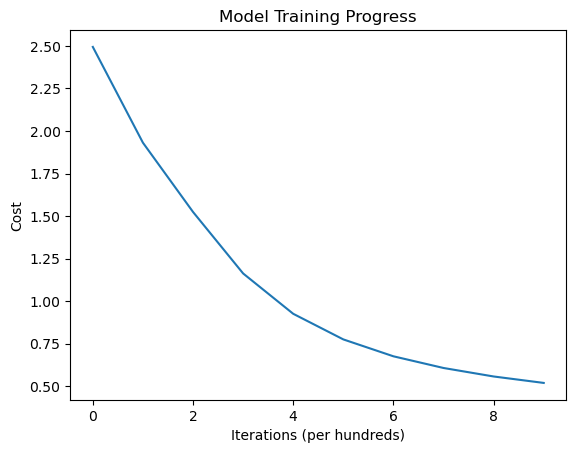

In [4]:
plt.plot(costs)
plt.ylabel('Cost')
plt.xlabel('Iterations (per hundreds)')
plt.title("Model Training Progress")
plt.show()

In [7]:
import numpy as np
from src.model import model_forward

def predict(X, parameters):
    """
    Using the learned parameters, predicts a class for each example in X
    """
    # 1. Run forward propagation once to get final output (AL)
    AL, _ = model_forward(X, parameters)
    
    # 2. Convert probabilities to class labels (0-9)
    # np.argmax picks the index with the highest value in each column
    predictions = np.argmax(AL, axis=0)
    
    return predictions

In [8]:
# 1. Load the test data
# Note: Using '../data/mnist_test.csv' based on your folder structure in image_e30c7e.png
X_test, Y_test = load_mnist_data('../data/mnist_test.csv')

# 2. Get predictions using our new function
test_predictions = predict(X_test, parameters)

# 3. Get the actual labels from your one-hot encoded Y_test
# If Y_test is (10, 10000), argmax gives us the index of the '1'
true_labels = np.argmax(Y_test, axis=0)

# 4. Calculate Accuracy
accuracy = np.mean(test_predictions == true_labels) * 100

print(f"Final Test Accuracy: {accuracy:.2f}%")

Final Test Accuracy: 87.48%


Total incorrect: 1252 out of 10,000


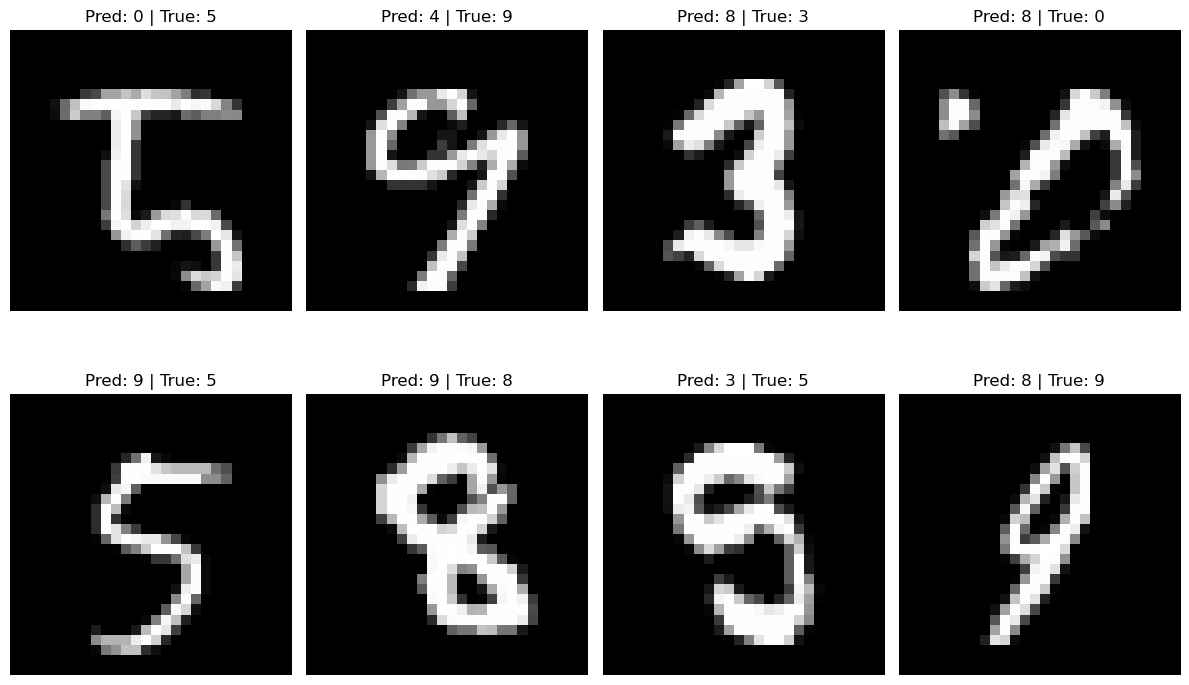

In [9]:
import matplotlib.pyplot as plt

# 1. Find indices of incorrect predictions
mismatches = np.where(test_predictions != true_labels)[0]
print(f"Total incorrect: {len(mismatches)} out of 10,000")

# 2. Plot a few examples of what the model missed
plt.figure(figsize=(12, 8))
for i, index in enumerate(mismatches[:8]): # Look at the first 8 errors
    plt.subplot(2, 4, i + 1)
    # Reshape the flattened 784 pixels back to 28x28 for display
    plt.imshow(X_test[:, index].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {test_predictions[index]} | True: {true_labels[index]}")
    plt.axis('off')

plt.tight_layout()
plt.show()